In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.odr import ODR, Model, RealData
import matplotlib.ticker as ticker

# ODR VELOCITà LIMITE

Definisco le incertezze su tempi e spazi

In [16]:
d=[0.0015,0.002, (4/32)*0.0254, (8/32)*0.0254, (9/32)*0.0254]

sx=[]
for a in range(0,len(d)):
    sx.append((d[a]/(np.sqrt(3))))
print(sx)

[np.float64(0.0008660254037844387), np.float64(0.0011547005383792516), np.float64(0.001833087104677062), np.float64(0.003666174209354124), np.float64(0.0041244459855233895)]


In [17]:
N=3
for i in range (0, len(sx)):
    sx[i]=np.sqrt(2)*sx[i]
print(sx)


[np.float64(0.0012247448713915891), np.float64(0.0016329931618554523), np.float64(0.0025923766444455303), np.float64(0.005184753288891061), np.float64(0.005832847450002444)]


Fit tramite ODR (numerico)

In [18]:
n_file=5
vlims=[]
svlims=[]


plt.figure(figsize=(10,10))

for j in range(1,n_file+1):
    data = np.loadtxt("R_NN"+str(j)+".txt")
    
    s = data[:,0]*10**(-2)
    t=(np.mean(data[:, 1:], axis=1))
    st=(np.std(data[:, 1:], axis=1)/np.sqrt(N))

    print("Inct:"+str(st))
    print(t)

    def linear_model_odr(beta, x):
        return beta[0] * x + beta[1]

    odr_model = Model(linear_model_odr)
    odr_data  = RealData(s, t, sx=sx[j-1], sy=st)

    odr_instance = ODR(
    odr_data,
    odr_model,
    beta0=[0.0, 0.0]   # valori iniziali
    )

    odr_result = odr_instance.run()

    vlim = 1/odr_result.beta[0]
    svlim = odr_result.sd_beta[0]/odr_result.beta[0]**2

    svlims.append(svlim)
    vlims.append(vlim)

    print("=== Risultati ODR " +str(j) +"===")
    print(f"  b = {odr_result.beta[0]:.10f} ± {odr_result.sd_beta[0]:.10f} ")
    print(f"  a = {odr_result.beta[1]:.10f} ± {odr_result.sd_beta[1]:.10f} ")
    print(f"  Vl = {vlim:.10f} ± {svlim:.10f} ")

print(svlims)
print(vlims)


Inct:[0.4592284  1.00335921 2.18340501 2.51262359 2.96375505 3.74779168
 4.2439241  4.75831436 5.16920177 5.82835113]
[ 51.3354     103.97143333 159.68333333 216.972      273.2259
 331.36196667 390.22373333 450.251      510.77626667 571.50923333]
=== Risultati ODR 1===
  b = 1141.1112108905 ± 8.9410227162 
  a = -8.5045183747 ± 1.7162009722 
  Vl = 0.0008763388 ± 0.0000068664 
Inct:[0.22647181 0.25771057 0.40003336 0.60152272 0.73167907 0.70561272
 0.95100439 1.05933914 1.15061709 0.92407988]
[ 27.4566      55.39526667  84.30266667 115.282      146.1836
 177.25513333 209.1634     241.4109     274.3999     308.00146667]
=== Risultati ODR 2===
  b = 622.7606918754 ± 5.6892025891 
  a = -7.3554028443 ± 1.5847219307 
  Vl = 0.0016057532 ± 0.0000146693 
Inct:[0.10289353 0.1249883  0.21007958 0.37113637 0.48556753 0.46193189
 0.51736431 0.5698842  0.62652293 0.65177936]
[ 10.61656667  21.55973333  32.9099      44.6304      56.6991
  69.04686667  81.43553333  94.07083333 106.65493333 119.5727

<Figure size 1000x1000 with 0 Axes>

## CALCOLO VISCOSITà E CORREZIONI 

VISCOSITà SENZA CORREZIONI:
[np.float64(9.564934492129717), np.float64(9.28010080032336), np.float64(9.087259363417942), np.float64(7.377974899941646), np.float64(6.457403190079062)]
[np.float64(0.20546488216836262), np.float64(0.20405659126529177), np.float64(0.19803192904859404), np.float64(0.1647689132215026), np.float64(0.13421947696589315)]


VELOCITà FONDO PARETE:
[np.float64(0.0009138986542654152), np.float64(0.0016975951908138), np.float64(0.004508613074350482), np.float64(0.02408500968595515), np.float64(0.035509656956476475)]
[np.float64(7.913854970430511e-06), np.float64(1.735142458105633e-05), np.float64(4.656972783101777e-05), np.float64(0.0003145780423156614), np.float64(0.00032366104237327426)]


VISCOSITà FONDO PARETE:
[np.float64(8.866012781814236), np.float64(8.485349360445165), np.float64(8.051714477577207), np.float64(6.028989091204014), np.float64(5.175471143546865)]
[np.float64(0.19323672852530782), np.float64(0.19059354167803919), np.float64(0.18125037438433855),

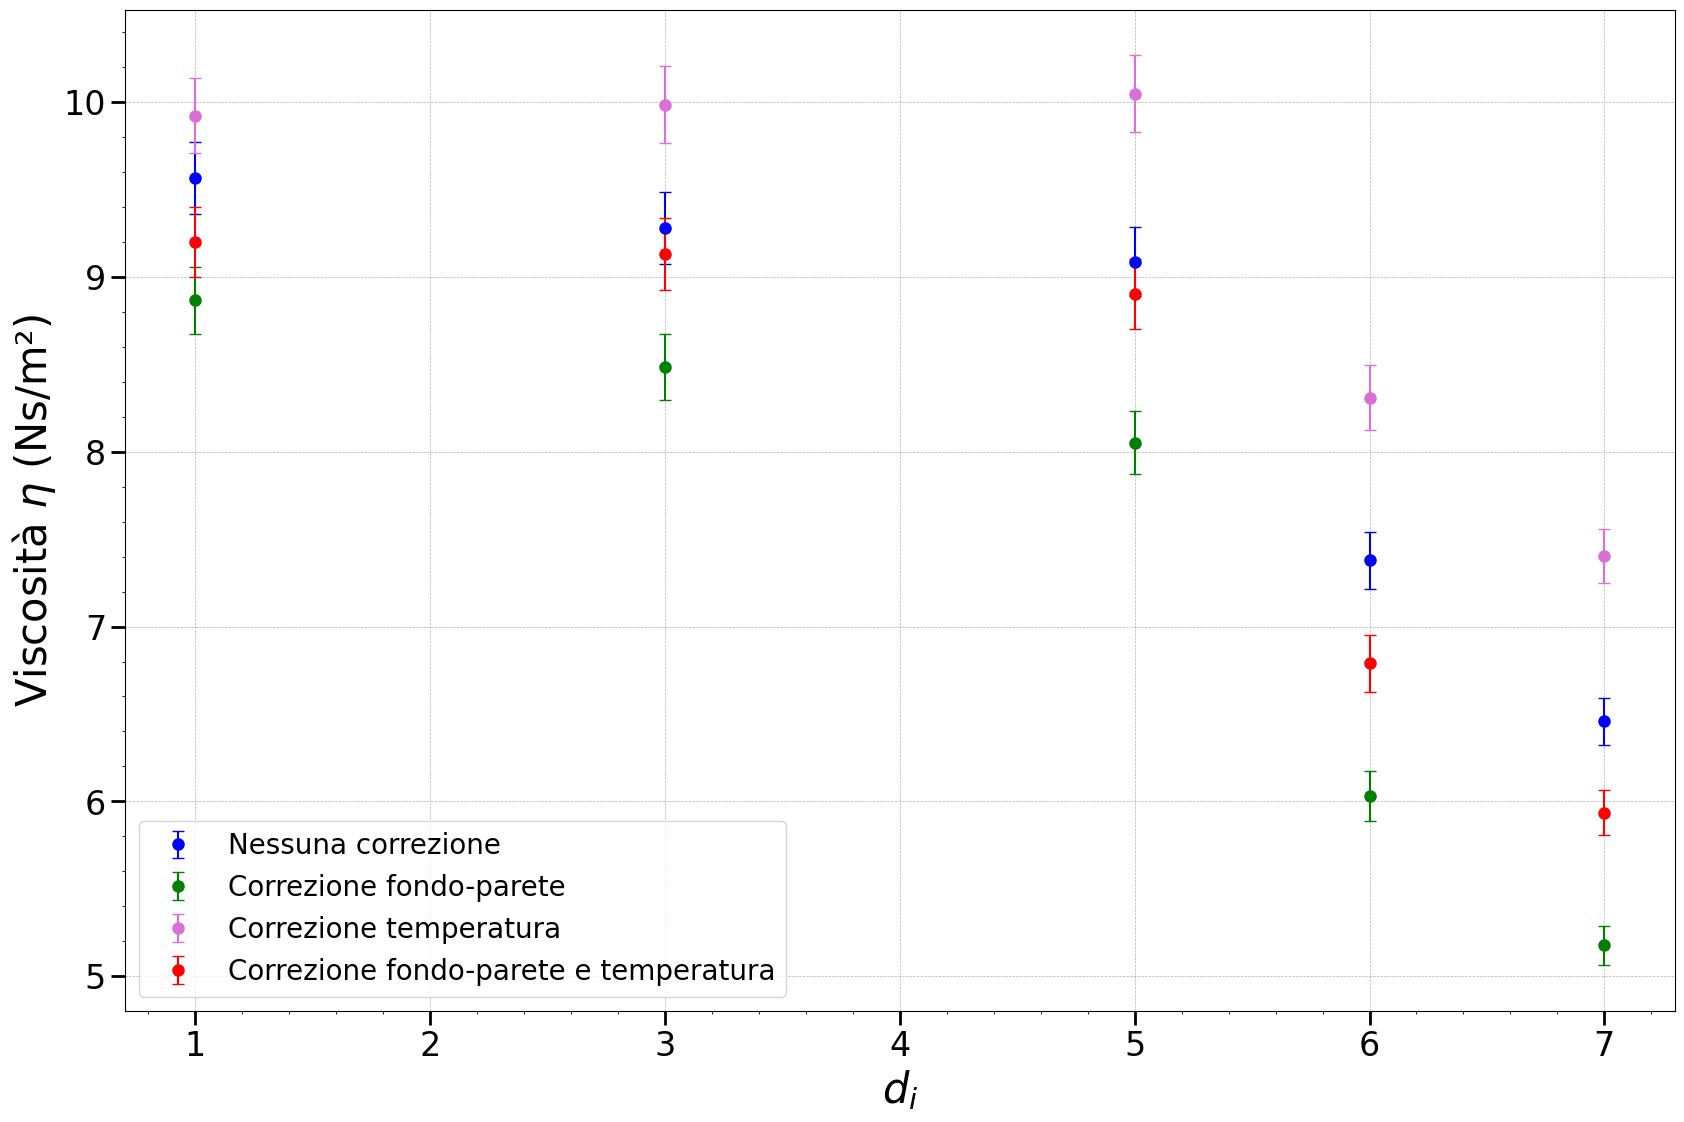

In [20]:
#DATI NON NEWTONIANO
eta=[]
s_eta=[]
p= 7.870 * 10**3
p0= 1.032 * 10**3 
sp=0.001 * 10**3
sp0=0.001 * 10**3
g=9.80652
sd=[]
for i in range(len(d)):
    sd.append(d[i]*0.01)

#CALCOLO VISCOSITà SENZA CORREZIONI
for i in range(0, len(vlims)):
    D = d[i]
    n = (1/18)*(g*(p-p0)*(D**2))/vlims[i]
    eta.append(n)
    s_n=np.sqrt((g*(p-p0)/(9*vlims[i])*D*sd[i])**2+((g*(p-p0)*D**2/(18*vlims[i]**2))*svlims[i])**2+(g*D**2/(18*vlims[i])*sp)**2+(g*D**2/(18*vlims[i])*sp0)**2)
    s_eta.append(s_n)

#Inizio grafico
plt.figure(figsize=(20,13))
x=[1,3,5,6,7] #Ordinali per i diametri
plt.errorbar(x, eta, fmt='o', yerr=s_eta, capsize=4, ms=8, color='blue', ecolor='blue', label='Nessuna correzione', zorder=2) #Visco senza correzioni
print("VISCOSITà SENZA CORREZIONI:")
print(eta)
print(s_eta)
print("\n")

#///////////////////////
#CORREZIONE SISTEMATICHE
#1) FONDO PARETE

vlimsFP=[]
svlimsFP=[]
R=4.5*10**(-2)
H=90*10**(-2) #Dati viscosimetro supposti privi di errore

#Calcolo velocità fondo-parete + incertezze propag.
for i in range(0, len(vlims)):
    D = d[i]
    r = D/2
    vlimsFP.append(vlims[i]*(1+2.4*r/R)*(1+3.3*r/H))
    svlimsFP.append(svlims[i]*(1+2.4*r/R)*(1+3.3*r/H)+vlims[i]*(2.4/R)*(1+3.3*r/H)*sd[i]+vlims[i]*(1+2.4*r/R)*3.3/H*sd[i])

print("VELOCITà FONDO PARETE:")
print(vlimsFP)
print(svlimsFP)
print("\n")


#Viscosità fondo-parete + incertezze propag.
etaFP=[]
s_etaFP=[]
for i in range(0, len(vlimsFP)):
    D = d[i]
    p= 7.870 * 10**3
    p0= 1.26 * 10**3 
    g= 9.80652
    n = (1/18)*(g*(p-p0)*(D**2))/vlimsFP[i]
    etaFP.append(n)
    s_etaFP.append(np.sqrt((g*(p-p0)/(9*vlimsFP[i])*D*sd[i])**2+((g*(p-p0)*D**2/(18*vlimsFP[i]**2))*svlimsFP[i])**2+(g*D**2/(18*vlimsFP[i])*sp)**2+(g*D**2/(18*vlimsFP[i])*sp0)**2))

plt.errorbar(x, etaFP, yerr=s_etaFP, fmt='o', capsize=4, ms=8, color='green', ecolor='green', label='Correzione fondo-parete', zorder=2)
print("VISCOSITà FONDO PARETE:")
print(etaFP)
print(s_etaFP)
print("\n")

#2) TEMPERATURA
#T0=20°C

#Si sceglie come valore di riferimento T=20°
T=[20.4, 20.8, 21.1, 21.3, 21.5]
etastar1=[1.3627, 1.3138, 1.2784, 1.2554, 1.2329]
etastar0=1.4138
etaTFP=[]
etaT=[]
s_etaT=[]
s_etaTFP=[]
for i in range(0, len(eta)):
    etaT.append(etastar0/etastar1[i]*eta[i])
    etaTFP.append(etastar0/etastar1[i]*etaFP[i])
    s_etaT.append(etastar0/etastar1[i]*s_eta[i])
    s_etaTFP.append(etastar0/etastar1[i]*s_etaFP[i])

print("VISCOSITà TEMPERATURA:")
print(etaT)
print(s_etaT)
print("\n")

print("VISCOSITà ENTRAMBE CORREZIONI:")
print(etaTFP)
print(s_etaTFP)
print("\n")

#Grafico
plt.errorbar(x, etaT, fmt='o', yerr=s_etaT, capsize=4, ms=8, color='orchid', ecolor='orchid', label='Correzione temperatura', zorder=2)
plt.errorbar(x, etaTFP, fmt='o', yerr=s_etaTFP, capsize=4, ms=8, color='red', ecolor='red', label='Correzione fondo-parete e temperatura', zorder=2)

#Grafico
plt.xlabel(f'$d_i$', fontsize=30)
plt.ylabel(f'Viscosità $\eta$ (Ns/m²)', fontsize=30)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
#plt.ylim(1.1,1.26)
plt.grid(linestyle='--', linewidth=0.5, alpha=0.6, color='gray')
plt.minorticks_on()
plt.legend(fontsize=20)
ax = plt.gca()
ax.tick_params(axis='both', which='major', labelsize=24, length=10, width=2)

In [25]:
(np.max(etaTFP) - np.min(etaTFP))/np.min(etaTFP)

np.float64(0.5499084937038222)